# Google Search Analysis Project

Suppose you are working in a data-driven job role. Your task is to find the answers to the following questions.

1) First, write the code where, just by changing the keyword, we can search for multiple things.

2) Top 15 countries whhere the keywords are searched the most. Also create an appealing visual representation.

3) A world map need to be plotted showing the countries that search a keyword the most.

4) Extract the time-wise interest of the keyword like how it trended in different years.

5) Compare related keywords and plot a graph.

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install pytrends

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

### **1) First, write the code where, just by changing the keyword, we can search for multiple things.**

In [3]:
trends = TrendReq(hl='en-US', tz=300)

keyword = input("Enter the keyword: ")

trends.build_payload([keyword], cat = 0, timeframe='today 12-m', geo='',gprop='')

Enter the keyword: artificial intelligence


### **2) Top 15 countries where the keywords are searched the most. Also create an appealing visual representation.**

In [5]:
reg_data = trends.interest_by_region()

reg_data = reg_data.sort_values(by = keyword, ascending = False).head(15)

<ipython-input-6-a9c74725523e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = reg_data[keyword], y = reg_data.index, palette = 'rocket')


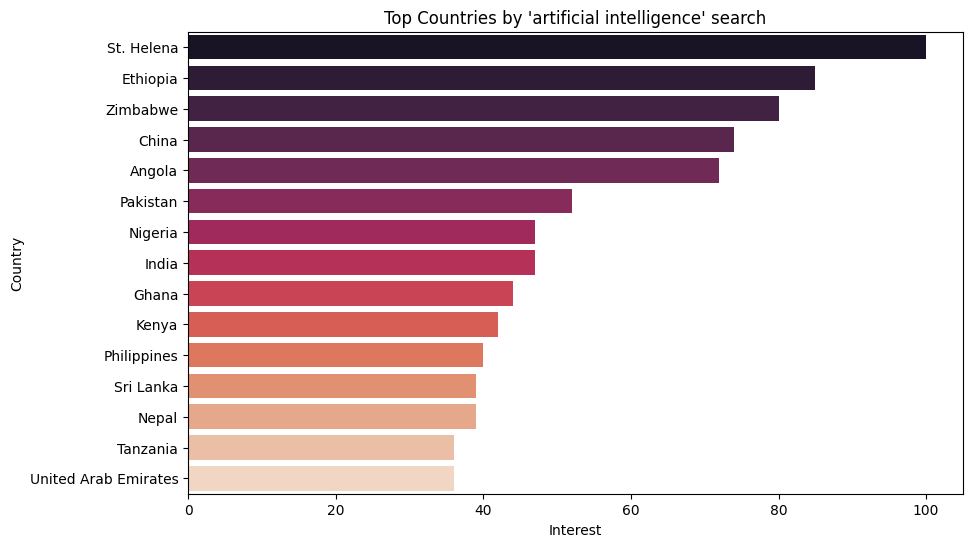

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x = reg_data[keyword], y = reg_data.index, palette = 'rocket')
plt.title(f"Top Countries by '{keyword}' search")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()

### **3) A world map need to be plotted showing the countries that search a keyword the most.**

In [8]:
reg_data = reg_data.reset_index()

fig = px.choropleth(reg_data,
                    locations='geoName',
                    locationmode='country names',
                    color=keyword,
                    title=f'Search Interest for "{keyword}" by countries',
                    color_continuous_scale='reds')

fig.show()

### **4) Extract the time-wise interest of the keyword like how it trended in different years.**

/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



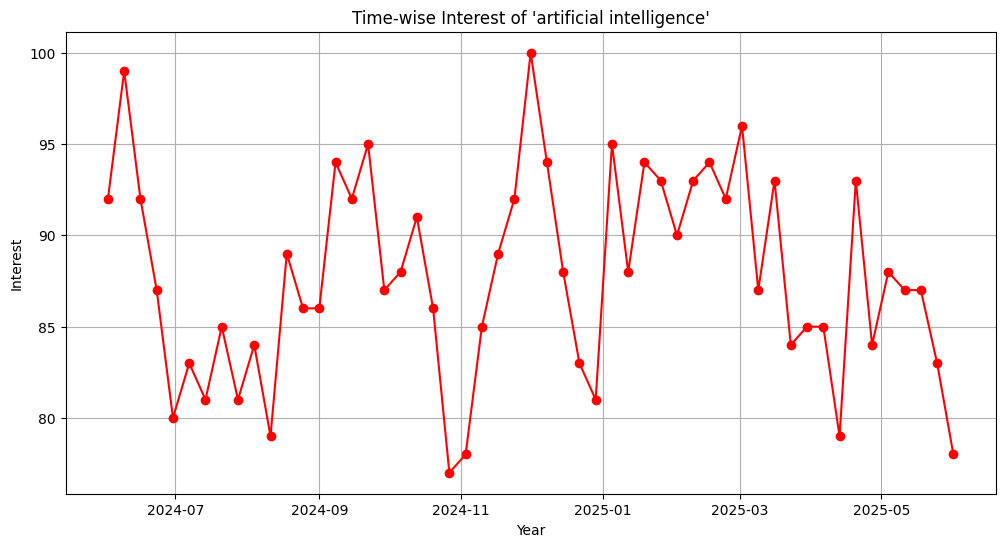

In [9]:
import time

time.sleep(5)

time_df = trends.interest_over_time()

plt.figure(figsize=(12, 6))
plt.plot(time_df.index, time_df[keyword], marker='o', linestyle='-', color = 'red')
plt.title(f"Time-wise Interest of '{keyword}'")
plt.xlabel("Year")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

### **5) Compare related keywords and plot a graph.**

/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



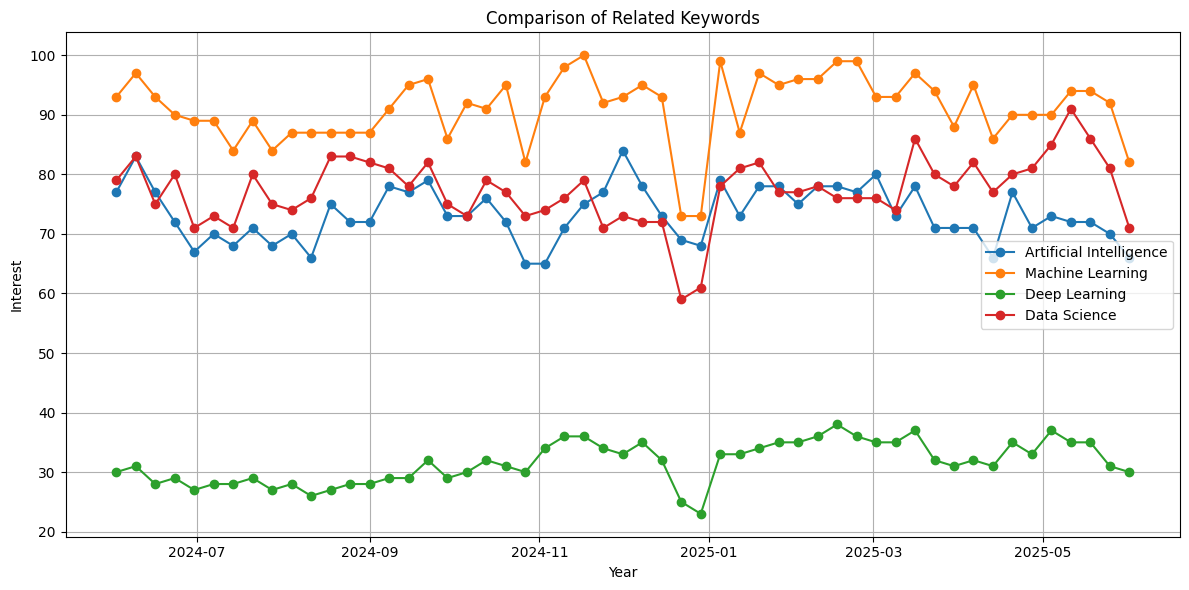

In [29]:
kw_list = [
    "Artificial Intelligence",
    "Machine Learning",
    "Deep Learning",
    "Data Science"
]

trends.build_payload(kw_list, cat=0, timeframe='today 12-m', geo='', gprop='')

compare_df = trends.interest_over_time()

plt.figure(figsize=(12, 6))

for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], marker='o', linestyle='-', label=kw)

plt.title("Comparison of Related Keywords")
plt.xlabel("Year")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()